## 3DoF Quadrotor SCP

Imports

In [1]:
# Basic imports
import importlib
import numpy as np
import matplotlib.pyplot as plt

# Trajopt imports --> pip install -e ~/ACL/trajopt
import trajopt; importlib.reload(trajopt)
import trajopt.core.modules.method.scp as scp
import trajopt.core.problem as prob
import trajopt.utils.config_loader as cfg
import trajopt.core.modules.analysis.standalone as standalone

setup problem and run SCP

In [2]:
example_name = "quadrotor_3dof"
nominal_config  = cfg.load_configs(example_name)

# create problem instance
problem = prob.Problem(nominal_config)

# run SCP
problem = scp.run_scp(problem)

# store scenario data struct for plotting
scenario_data = standalone.run_standalone_analysis(problem)

scales: 
d: 1.0000, t: 1.0000, m: 1.0000, v: 1.0000, a: 1.0000, f: 1.0000, ang: 57.2958, angv: 57.2958
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: quadrotor: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   time [ms]  | time [ms] |  time [ms] |           |  (path + NFZ)   |  (terminal) |  (dynamics) |              |  Flight [s] |           
--------------------------------------------------------------------------------------------------------------------------------------------------------


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    00388.5   |   0006.1  |   2934.5   |   +0.4    |      -12.0      |    -12.0    |     -12.0   |    optimal    |   7.00   |  522.7
     02     |    00003.5   |   0006.2  |   0000.7   |   -1.2    |      -12.0      |    -12.0    |     -12.0   |    optimal    |   7.00   |  516.5
Terminated from convergence criteria!


make plots

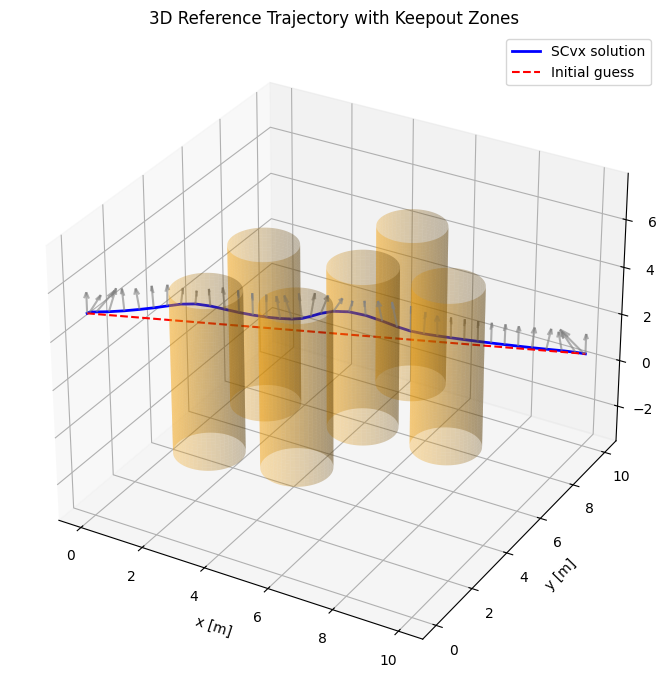

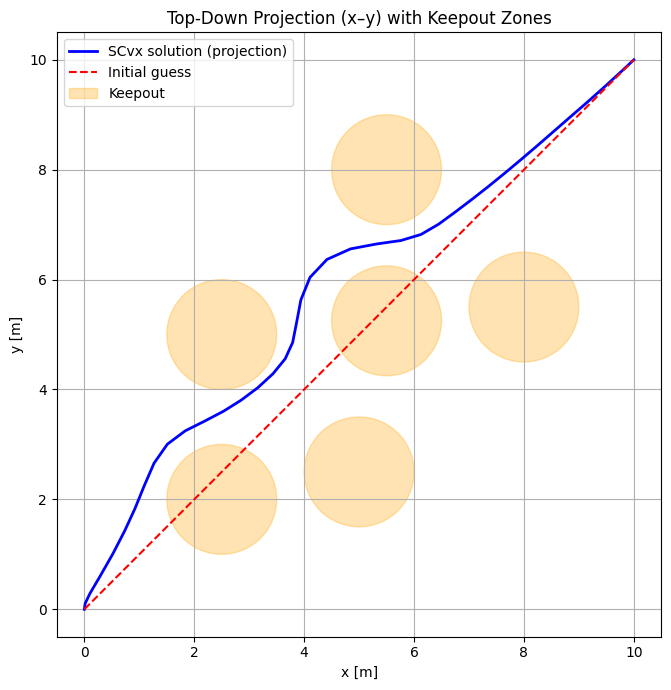

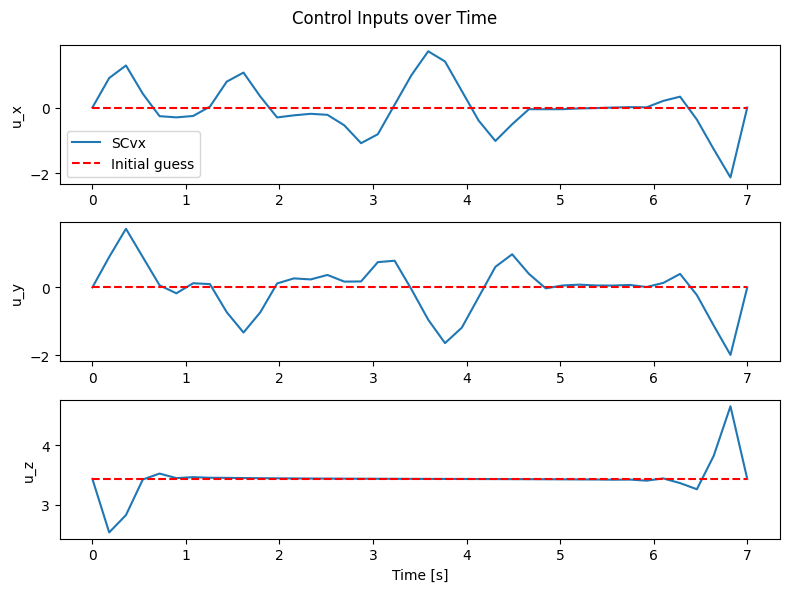

In [3]:
# --- 3D Interactivity (run %matplotlib widget in Jupyter) ---
# run this once per notebook session
#%matplotlib widget

mission = problem.mission
model   = problem.model
method  = problem.method

# --- Retrieve trajectory and parameters ---

t_init = method.t_init
z_init = method.z_init
nu_init = method.nu_init
x_init  = z_init[:, 0]
y_init  = z_init[:, 1]
z_init  = z_init[:, 2]

t_opt  = problem.solution["ts"]
z_opt  = problem.solution["zs"]
nu_opt  = problem.solution["us"]

# ============================================================
# 3D Trajectory Plot
# ============================================================
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

# --- Trajectories ---
ax.plot(z_opt[:, 0], z_opt[:, 1], z_opt[:, 2],
        'b-', linewidth=2, label="SCvx solution")
ax.plot(x_init, y_init, z_init,
        'r--', linewidth=1.5, label="Initial guess")

# --- Thrust vectors (downsampled for clarity) ---
nu_opt_scaled = 0.25 * nu_opt
skip = max(1, len(z_opt) // 25)
ax.quiver(
    z_opt[::skip, 0], z_opt[::skip, 1], z_opt[::skip, 2],
    nu_opt_scaled[::skip, 0], nu_opt_scaled[::skip, 1], nu_opt_scaled[::skip, 2],
    length=1.0, normalize=False, color='gray', alpha=0.6
)

# ============================================================
# Cylindrical Keepout Zones
# ============================================================
n_nfz = mission.n_nfz
z_traj_max = np.max(z_opt[:, 2])
z_traj_min = np.min(z_opt[:, 2])
height = (z_traj_max - z_traj_min) * 1.5  # cylinders taller than trajectory
z_bottom = z_traj_min - 0.25 * height
z_top = z_bottom + height

for i in range(n_nfz):
    xc = mission.obs['xc'][i]
    yc = mission.obs['yc'][i]
    rc = mission.obs['rc'][i]

    s = np.linspace(0, 2 * np.pi, 100)
    z = np.linspace(z_bottom, z_top, 50)
    S, Z = np.meshgrid(s, z)
    X = xc + rc * np.cos(S)
    Y = yc + rc * np.sin(S)
    ax.plot_surface(X, Y, Z, color='orange', alpha=0.3, linewidth=0, shade=True)

# ============================================================
# Equal Axis Scaling
# ============================================================
def set_axes_equal(ax):
    """Make 3D axes have equal scale."""
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()
    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])
    max_range = max([x_range, y_range, z_range]) / 2.0
    mid_x = np.mean(x_limits)
    mid_y = np.mean(y_limits)
    mid_z = np.mean(z_limits)
    ax.set_xlim3d([mid_x - max_range, mid_x + max_range])
    ax.set_ylim3d([mid_y - max_range, mid_y + max_range])
    ax.set_zlim3d([mid_z - max_range, mid_z + max_range])

set_axes_equal(ax)

# --- Labels, Legend ---
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title("3D Reference Trajectory with Keepout Zones")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# Top-Down Projection (x–y plane)
# ============================================================
fig, ax2d = plt.subplots(figsize=(7, 7))

# Plot trajectory footprints
ax2d.plot(z_opt[:, 0], z_opt[:, 1], 'b-', linewidth=2, label="SCvx solution (projection)")
ax2d.plot(x_init, y_init, 'r--', linewidth=1.5, label="Initial guess")

# Plot circular obstacle projections
for i in range(n_nfz):
    xc = mission.obs['xc'][i]
    yc = mission.obs['yc'][i]
    rc = mission.obs['rc'][i]
    circle = plt.Circle((xc, yc), rc, color='orange', alpha=0.3, label="Keepout" if i == 0 else None)
    ax2d.add_patch(circle)

ax2d.set_aspect('equal', adjustable='box')
ax2d.set_xlabel("x [m]")
ax2d.set_ylabel("y [m]")
ax2d.set_title("Top-Down Projection (x–y) with Keepout Zones")
ax2d.grid(True)
ax2d.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 2D Control vs Time Plot
# ============================================================
fig = plt.figure(figsize=(8, 6))
ax_1 = fig.add_subplot(311)
ax_2 = fig.add_subplot(312)
ax_3 = fig.add_subplot(313)

ax_1.plot(t_opt, nu_opt[:, 0], label="SCvx")
ax_1.plot(t_init, nu_init[:, 0], 'r--', label="Initial guess")
ax_1.set_ylabel("u_x")

ax_2.plot(t_opt, nu_opt[:, 1])
ax_2.plot(t_init, nu_init[:, 1], 'r--')
ax_2.set_ylabel("u_y")

ax_3.plot(t_opt, nu_opt[:, 2])
ax_3.plot(t_init, nu_init[:, 2], 'r--')
ax_3.set_ylabel("u_z")
ax_3.set_xlabel("Time [s]")

ax_1.legend()
plt.suptitle("Control Inputs over Time")
plt.tight_layout()
plt.show()